#   LangGraph 활용 - 서브 그래프 (Sub-graph)

---

## 환경 설정 및 준비

`(1) Env 환경변수`

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [2]:
import os
from glob import glob

from pprint import pprint
import json

`(3) langfuase handler 설정`

In [4]:
from langfuse.langchain import CallbackHandler

# 콜백 핸들러 생성
langfuse_handler = CallbackHandler()

---

## **Sub-graph (서브그래프)**

- **서브그래프란?**

    - 서브그래프는 **그래프를 다른 그래프의 노드로 사용하는 캡슐화 개념**
    - 이를 통해 복잡한 시스템을 여러 컴포넌트로 구성할 수 있음 

- **서브그래프 사용 이유**
    - **다중 에이전트 시스템(Multi-agent systems)** 구축
    - **재사용성**: 여러 그래프에서 동일한 노드 집합 재사용
    - **모듈화**: 독립적인 팀이 각자 담당 부분을 개발
    - **인터페이스 분리**: 입출력 스키마만 유지하면 내부 구현은 자유롭게 변경 가능


- **서브그래프 사용 방식**

    - **방식 1: 직접 노드 추가 (Direct Node Addition)**

        - 부모와 서브그래프가 동일한 상태 키를 공유
        - 서브그래프를 직접 노드로 추가 가능

            ```python
            # 서브그래프를 컴파일 후 직접 노드로 추가
            parent_builder.add_node("subgraph_node", subgraph)
            ```

    - **방식 2: 호출 노드 사용 (Wrapper Node)**

        - 부모와 서브그래프가 다른 상태 스키마 사용
        - 노드 내부에서 서브그래프 호출 및 상태 변환 필요   

            ```python
            def call_subgraph(state):
                
                # 복잡한 제어 로직
                if state['data_type'] == 'image':

                    # 상태 변환 + (이미지) 서브그래프 호출 + 결과 변환
                    subgraph_input = transform_state(state)
                    result = image_subgraph.invoke(subgraph_input)
                    return transform_result(result)

                elif state['data_type'] == 'text':
                    
                    # 상태 변환 + (텍스트) 서브그래프 호출 + 결과 변환
                    subgraph_input = transform_state(state)
                    result = text_subgraph.invoke(subgraph_input)
                    return transform_result(result)

                else:

                    # 기본 처리 (Fallback)
                    return fallback_processing(state)


            parent_builder.add_node("wrapper_node", call_subgraph)
            ```

    - **두 방식 비교**

        | 특징 | 직접 노드 추가 | 호출 노드 사용 |
        |------|----------------|----------------|
        | **상태 스키마** | 반드시 호환 필요 | 독립적 가능 (다른 스키마) |
        | **상태 변환** | 자동 | 수동 구현 필요 |
        | **에러 처리** | 기본 처리 | 커스텀 처리 가능 |
        | **유연성** | 제한적 | 높음 |

---

### **[예제 1] 간단한 덧셈, 곱셈 연산을 수행하는 그래프**

1.  **부모 그래프 (Parent Graph):**
    - 사용자로부터 두 개의 숫자를 입력받습니다 (예: `num1`, `num2`).
    - `calculate`라는 서브그래프를 호출합니다.
    *  서브그래프의 결과를 출력합니다

2.  **서브그래프 (Subgraph):**
    - **`add` 노드:** 두 숫자를 더합니다.
    - **`multiply` 노드:** 두 숫자를 곱합니다.
    - 더한 결과와 곱한 결과를 부모 그래프에 반환합니다.

#### **1) 직접 노드 추가 (Direct Node Addition) 방식**

- 부모와 서브그래프 스키마가 호환되는 경우
- 단순하고 직관적인 구조를 원할 때

In [5]:
from langgraph.graph import StateGraph, MessagesState, START, END
from typing import TypedDict
from IPython.display import Image, display

# 공유 상태 정의
class SharedState(TypedDict):
    num1: int
    num2: int
    sum_val: int
    product_val: int
    final_val: int

# 서브그래프 노드들
def add_node(state: SharedState):
    return {"sum_val": state["num1"] + state["num2"]}

def multiply_node(state: SharedState):
    return {"product_val": state["num1"] * state["num2"]}

# 서브그래프 생성
subgraph_builder = StateGraph(SharedState)
subgraph_builder.add_node("add", add_node)
subgraph_builder.add_node("multiply", multiply_node)

subgraph_builder.add_edge(START, "add")
subgraph_builder.add_edge(START, "multiply")
subgraph_builder.add_edge(["add", "multiply"], END)

subgraph = subgraph_builder.compile()

# 서브그래프 시각화
# display(Image(subgraph.get_graph().draw_mermaid_png()))

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	add(add)
	multiply(multiply)
	__end__([<p>__end__</p>]):::last
	__start__ --> add;
	__start__ --> multiply;
	add --> __end__;
	multiply --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

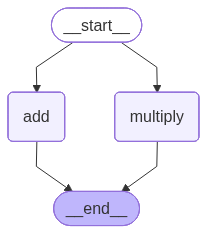

In [10]:
from langchain_core.runnables.graph import CurveStyle
from IPython.display import Markdown, display
from IPython.display import Image, display

mermaid_code = subgraph.get_graph().draw_mermaid()
display(Markdown(f"```mermaid\n{mermaid_code}\n```"))

graph=subgraph
display(Image(graph.get_graph().draw_mermaid_png()))

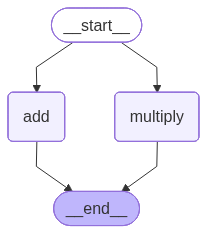

In [11]:
from langgraph.checkpoint.memory import InMemorySaver

# 부모 그래프 생성
parent_builder = StateGraph(SharedState)

# 부모 그래프 노드
def finalize_node(state: SharedState):
    sum_val = state.get("sum_val", 0)
    product_val = state.get("product_val", 0)
    final_val = sum_val + product_val
    return {"final_val": final_val}

# 컴파일된 서브그래프를 직접 노드로 추가
parent_builder.add_node("calculate", subgraph)
parent_builder.add_node("finalize", finalize_node)

parent_builder.add_edge(START, "calculate")
parent_builder.add_edge("calculate", "finalize")
parent_builder.add_edge("finalize", END)

parent_graph = parent_builder.compile(checkpointer=InMemorySaver())

# 부모 그래프 시각화
# display(Image(parent_graph.get_graph(xray=True).draw_mermaid_png()))
display(Image(graph.get_graph().draw_mermaid_png()))

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	finalize(finalize)
	__end__([<p>__end__</p>]):::last
	__start__ --> calculate___start__;
	calculate___end__ --> finalize;
	finalize --> __end__;
	subgraph calculate
	calculate___start__(<p>__start__</p>)
	calculate_add(add)
	calculate_multiply(multiply)
	calculate___end__(<p>__end__</p>)
	calculate___start__ --> calculate_add;
	calculate___start__ --> calculate_multiply;
	calculate_add --> calculate___end__;
	calculate_multiply --> calculate___end__;
	end
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

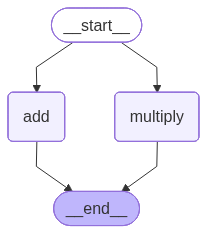

In [12]:
from langchain_core.runnables.graph import CurveStyle
from IPython.display import Markdown, display

mermaid_code = parent_graph.get_graph(xray=True).draw_mermaid()
display(Markdown(f"```mermaid\n{mermaid_code}\n```"))

display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
# 메인 그래프 실행
config = {"configurable": {"thread_id": "direct_1"}}

for step in parent_graph.stream(
    {"num1": 5, "num2": 3}, 
    config,
    stream_mode="updates"
):
    print(step)
    print("-" * 100)

{'calculate': {'num1': 5, 'num2': 3, 'sum_val': 8, 'product_val': 15}}
----------------------------------------------------------------------------------------------------
{'finalize': {'final_val': 23}}
----------------------------------------------------------------------------------------------------


In [14]:
# 스트리밍으로 실행 과정 관찰
config = {"configurable": {"thread_id": "direct_1"}}

for step in parent_graph.stream(
    {"num1": 5, "num2": 3}, 
    config,
    stream_mode="updates",
    subgraphs=True  # 서브그래프 내부 스트리밍
):
    print(step)
    print("-" * 100)

(('calculate:80732293-d333-6839-3623-f8d1cbd24970',), {'add': {'sum_val': 8}})
----------------------------------------------------------------------------------------------------
(('calculate:80732293-d333-6839-3623-f8d1cbd24970',), {'multiply': {'product_val': 15}})
----------------------------------------------------------------------------------------------------
((), {'calculate': {'num1': 5, 'num2': 3, 'sum_val': 8, 'product_val': 15, 'final_val': 23}})
----------------------------------------------------------------------------------------------------
((), {'finalize': {'final_val': 23}})
----------------------------------------------------------------------------------------------------


#### **2) 호출 노드 사용 (Wrapper Node) 방식**

- 부모와 서브그래프 스키마가 다른 경우
- 서브그래프 실행 전후에 복잡한 처리가 필요할 때
- 에러 처리, 검증, 로깅 등 세밀한 제어가 필요할 때
- 조건부 실행이나 동적 파라미터 전달이 필요할 때
- 기존 코드와의 호환성이 중요할 때

In [16]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from typing import TypedDict
from datetime import datetime

# 서브그래프 상태 (다른 키 사용)
class SubgraphState(TypedDict):
    a: int
    b: int
    sum: int
    product: int

# 부모 그래프 상태
class ParentState(TypedDict):
    num1: int
    num2: int
    sum_val: int
    product_val: int
    final_val: int

# 서브그래프 노드들
def add_node(state: SubgraphState):
    print(f"  🔢 덧셈 계산: {state['a']} + {state['b']} = {state['a'] + state['b']}")
    return {"sum": state["a"] + state["b"]}

def multiply_node(state: SubgraphState):
    print(f"  🔢 곱셈 계산: {state['a']} × {state['b']} = {state['a'] * state['b']}")
    return {"product": state["a"] * state["b"]}

# 서브그래프 생성
subgraph_builder = StateGraph(SubgraphState)
subgraph_builder.add_node("add", add_node)
subgraph_builder.add_node("multiply", multiply_node)

subgraph_builder.add_edge(START, "add")
subgraph_builder.add_edge(START, "multiply")
subgraph_builder.add_edge(["add", "multiply"], END)
subgraph = subgraph_builder.compile()

# 래퍼 함수 - 서브그래프 호출 및 상태 변환 (서브 그래프 제어 및 커스텀 로깅)
def call_subgraph(state: ParentState):
    print(f"\n📋 래퍼 함수 시작 - 입력 상태: {state}")
    
    # 실행 전 로깅
    start_time = datetime.now()
    print(f"⏰ 서브그래프 실행 시작: {start_time.strftime('%H:%M:%S.%f')[:-3]}")

    # 실행 전 검증 (정수가 아닌 경우, 정수로 변환)
    if not isinstance(state["num1"], int) or not isinstance(state["num2"], int):
        print(f"⚠️ 타입 변환 필요: {type(state['num1'])}, {type(state['num2'])}")
        state["num1"] = int(state["num1"])
        state["num2"] = int(state["num2"])
        print(f"✅ 타입 변환 완료: {state['num1']}, {state['num2']}")
  
    # 부모 상태 → 서브그래프 상태 변환 (부모 키를 서브그래프 키에 매핑)
    subgraph_input = {"a": state["num1"], "b": state["num2"]}
    print(f"🔄 서브그래프 입력 변환: {subgraph_input}")

    try:
        # 서브그래프 실행
        print("🚀 서브그래프 실행 중...")
        result = subgraph.invoke(subgraph_input)
        print(f"📤 서브그래프 출력: {result}")
        
        # 실행 후 처리
        end_time = datetime.now()
        execution_time = (end_time - start_time).total_seconds()
        print(f"✅ 서브그래프 실행 완료: {execution_time:.4f}초")
        
        # 서브그래프 결과 → 부모 상태 변환 (결과 수정 가능)
        modified_result = {
            "sum_val": result["sum"] * 10,   # 서브그래프 결과 수정 (10배)
            "product_val": result["product"] * 10,
        }
        print(f"🔧 결과 수정 적용 (10배): {modified_result}")
        return modified_result
        
    except Exception as e:
        print(f"❌ 서브그래프 실행 실패: {e}")
        return {
            "sum_val": 0,
            "product_val": 0
        }

# 부모 그래프 노드
def finalize_node(state: ParentState):
    print(f"\n🎯 최종 처리 노드 - 입력 상태: {state}")
    
    sum_val = state.get("sum_val", 0)
    product_val = state.get("product_val", 0)
    
    # final_val 계산
    final_val = sum_val + product_val
    
    print(f"🧮 최종 값 계산 결과: {final_val}")
    
    return {"final_val": final_val}

# 부모 그래프 생성
parent_builder = StateGraph(ParentState)
parent_builder.add_node("calculate", call_subgraph)
parent_builder.add_node("finalize", finalize_node)

parent_builder.add_edge(START, "calculate")
parent_builder.add_edge("calculate", "finalize")
parent_builder.add_edge("finalize", END)

# 체크포인터 추가
parent_graph = parent_builder.compile(checkpointer=InMemorySaver())

# 부모 그래프 시각화
# display(Image(parent_graph.get_graph(xray=True).draw_mermaid_png()))

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	finalize(finalize)
	__end__([<p>__end__</p>]):::last
	__start__ --> calculate___start__;
	calculate___end__ --> finalize;
	finalize --> __end__;
	subgraph calculate
	calculate___start__(<p>__start__</p>)
	calculate_add(add)
	calculate_multiply(multiply)
	calculate___end__(<p>__end__</p>)
	calculate___start__ --> calculate_add;
	calculate___start__ --> calculate_multiply;
	calculate_add --> calculate___end__;
	calculate_multiply --> calculate___end__;
	end
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

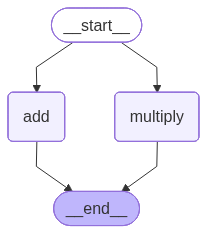

In [18]:
from langchain_core.runnables.graph import CurveStyle
from IPython.display import Markdown, display

mermaid_code = parent_graph.get_graph(xray=True).draw_mermaid()
display(Markdown(f"```mermaid\n{mermaid_code}\n```"))

display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
# 테스트 케이스 1: 정수 입력

config = {"configurable": {"thread_id": "test_1"}}

for step in parent_graph.stream(
    {"num1": 5, "num2": 3}, 
    config,
    stream_mode="updates"
):
    print(step)
    print("-" * 100)


📋 래퍼 함수 시작 - 입력 상태: {'num1': 5, 'num2': 3}
⏰ 서브그래프 실행 시작: 09:26:06.907
🔄 서브그래프 입력 변환: {'a': 5, 'b': 3}
🚀 서브그래프 실행 중...
  🔢 덧셈 계산: 5 + 3 = 8
  🔢 곱셈 계산: 5 × 3 = 15
📤 서브그래프 출력: {'a': 5, 'b': 3, 'sum': 8, 'product': 15}
✅ 서브그래프 실행 완료: 0.0413초
🔧 결과 수정 적용 (10배): {'sum_val': 80, 'product_val': 150}
{'calculate': {'sum_val': 80, 'product_val': 150}}
----------------------------------------------------------------------------------------------------

🎯 최종 처리 노드 - 입력 상태: {'num1': 5, 'num2': 3, 'sum_val': 80, 'product_val': 150}
🧮 최종 값 계산 결과: 230
{'finalize': {'final_val': 230}}
----------------------------------------------------------------------------------------------------


In [20]:
# 테스트 케이스 2: 문자열 입력 (타입 변환 테스트)

config = {"configurable": {"thread_id": "test_2"}}

for step in parent_graph.stream(
    {"num1": "7", "num2": "4"}, 
    config,
    stream_mode="updates"
):
    print(step)
    print("-" * 100)


📋 래퍼 함수 시작 - 입력 상태: {'num1': '7', 'num2': '4'}
⏰ 서브그래프 실행 시작: 09:26:30.351
⚠️ 타입 변환 필요: <class 'str'>, <class 'str'>
✅ 타입 변환 완료: 7, 4
🔄 서브그래프 입력 변환: {'a': 7, 'b': 4}
🚀 서브그래프 실행 중...
  🔢 덧셈 계산: 7 + 4 = 11
  🔢 곱셈 계산: 7 × 4 = 28
📤 서브그래프 출력: {'a': 7, 'b': 4, 'sum': 11, 'product': 28}
✅ 서브그래프 실행 완료: 0.0185초
🔧 결과 수정 적용 (10배): {'sum_val': 110, 'product_val': 280}
{'calculate': {'sum_val': 110, 'product_val': 280}}
----------------------------------------------------------------------------------------------------

🎯 최종 처리 노드 - 입력 상태: {'num1': '7', 'num2': '4', 'sum_val': 110, 'product_val': 280}
🧮 최종 값 계산 결과: 390
{'finalize': {'final_val': 390}}
----------------------------------------------------------------------------------------------------
